# 😊 Face Emotion Recognition — COMPLETE READY MODEL
### Just Run All Cells — No Changes Needed!

| Item | Detail |
|------|--------|
| **Dataset Path** | `C:\Users\2005a\FED\archive` |
| **Model** | Custom Deep CNN (4 Conv Blocks) |
| **Emotions** | Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise |
| **Input Size** | 48 × 48 Grayscale |
| **Output** | Trained model `.h5` + Real-time webcam detection |

---
> ✅ **How to use:** Click `Kernel → Restart & Run All` — everything runs automatically!

## 📦 STEP 1 — Install Required Libraries

In [1]:
import sys
!{sys.executable} -m pip install tensorflow opencv-python matplotlib seaborn scikit-learn numpy pandas --quiet
print('✅ All libraries installed!')

✅ All libraries installed!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 STEP 2 — Import All Libraries

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import classification_report, confusion_matrix

print('=' * 50)
print(f'  TensorFlow : {tf.__version__}')
print(f'  OpenCV     : {cv2.__version__}')
print(f'  NumPy      : {np.__version__}')
print('  GPU        :', tf.config.list_physical_devices("GPU") or 'CPU only')
print('=' * 50)
print('✅ All imports successful!')

  TensorFlow : 2.21.0
  OpenCV     : 4.13.0
  NumPy      : 2.1.3
  GPU        : CPU only
✅ All imports successful!


## 📁 STEP 3 — Dataset Path Configuration

In [3]:
#  ✅ YOUR DATASET PATH — Already set, no changes needed!

BASE_DIR  = r'C:\Users\2005a\FED\archive'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# ── Verify paths ──
for label, path in [('Base', BASE_DIR), ('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f'  {label:5s} Dir : {status}  →  {path}')

assert os.path.exists(TRAIN_DIR), f'Train folder missing: {TRAIN_DIR}'
assert os.path.exists(TEST_DIR),  f'Test  folder missing: {TEST_DIR}'

# ── Auto-detect class labels from folder names ──
EMOTION_LABELS = sorted([d for d in os.listdir(TRAIN_DIR)
                         if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES    = len(EMOTION_LABELS)

# ── Hyper-parameters ──
IMG_SIZE   = 48
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 0.001
MODEL_PATH = 'emotion_model_best.h5'

print(f'\n  Emotions   : {EMOTION_LABELS}')
print(f'  Classes    : {NUM_CLASSES}')
print(f'  Image Size : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch Size : {BATCH_SIZE}')
print(f'  Epochs     : {EPOCHS}')
print('\n✅ Configuration complete!')

  Base  Dir : ✅  →  C:\Users\2005a\FED\archive
  Train Dir : ✅  →  C:\Users\2005a\FED\archive\train
  Test  Dir : ✅  →  C:\Users\2005a\FED\archive\test

  Emotions   : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Classes    : 7
  Image Size : 48x48
  Batch Size : 64
  Epochs     : 20

✅ Configuration complete!


## 📊 STEP 4 — Explore & Visualize Dataset


📊 Dataset Distribution:
───────────────────────────────────
 Emotion  Train  Test
   angry   3995   958
 disgust    436   111
    fear   4097  1024
   happy   7215  1774
 neutral   4965  1233
     sad   4830  1247
surprise   3171   831
───────────────────────────────────
  Total Train : 28,709
  Total Test  : 7,178
  Grand Total : 35,887


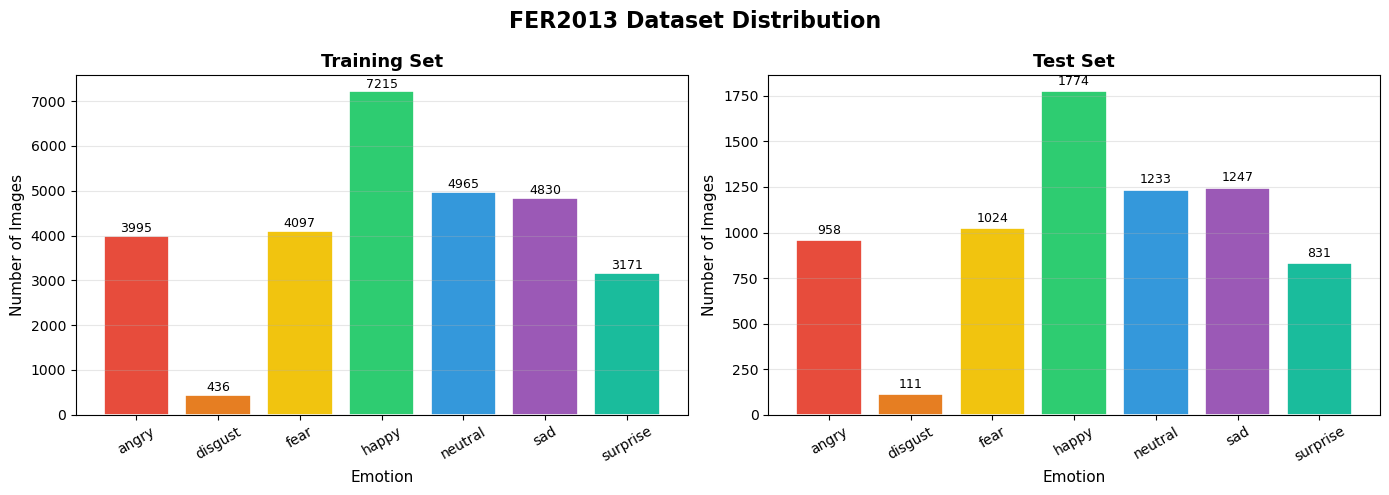

✅ Chart saved → 1_dataset_distribution.png


In [4]:
# ── Count images per class ──
def count_images(directory):
    return {e: len(os.listdir(os.path.join(directory, e)))
            for e in EMOTION_LABELS
            if os.path.isdir(os.path.join(directory, e))}

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df = pd.DataFrame({
    'Emotion': EMOTION_LABELS,
    'Train'  : [train_counts.get(e, 0) for e in EMOTION_LABELS],
    'Test'   : [test_counts.get(e,  0) for e in EMOTION_LABELS]
})

print('\n📊 Dataset Distribution:')
print('─' * 35)
print(df.to_string(index=False))
print('─' * 35)
print(f'  Total Train : {df["Train"].sum():,}')
print(f'  Total Test  : {df["Test"].sum():,}')
print(f'  Grand Total : {df[["Train","Test"]].sum().sum():,}')

# ── Bar chart ──
COLORS = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FER2013 Dataset Distribution', fontsize=16, fontweight='bold')

for ax, split, title in zip(axes, ['Train', 'Test'], ['Training Set', 'Test Set']):
    bars = ax.bar(df['Emotion'], df[split], color=COLORS, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('1_dataset_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Chart saved → 1_dataset_distribution.png')

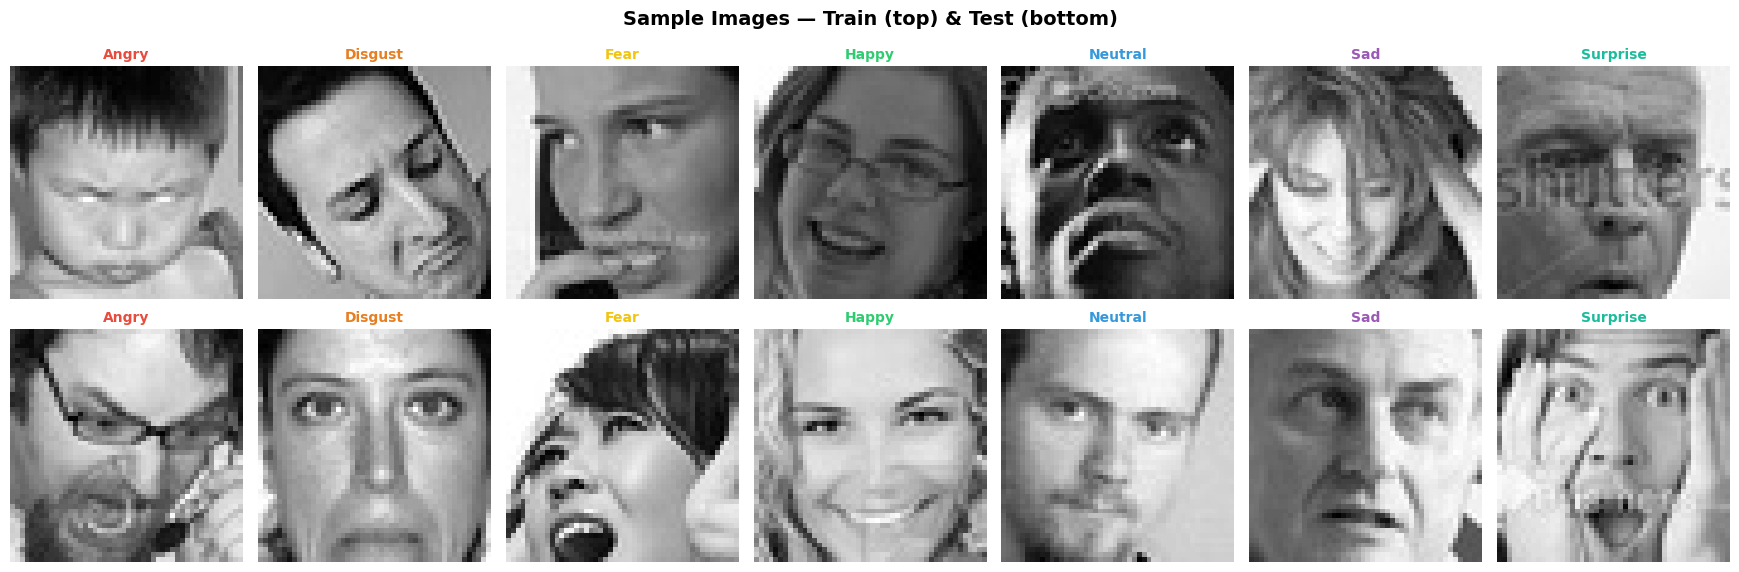

✅ Sample images saved → 2_sample_images.png


In [5]:
# ── Sample images from each emotion ──
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2.5, 6))
fig.suptitle('Sample Images — Train (top) & Test (bottom)', fontsize=14, fontweight='bold')

for col, emotion in enumerate(EMOTION_LABELS):
    for row, directory in enumerate([TRAIN_DIR, TEST_DIR]):
        folder = os.path.join(directory, emotion)
        files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        if files:
            img = cv2.imread(os.path.join(folder, files[0]), cv2.IMREAD_GRAYSCALE)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(emotion.capitalize(), fontsize=10,
                                     color=COLORS[col], fontweight='bold')
        axes[row, col].axis('off')

for row, label in enumerate(['Train', 'Test']):
    axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('2_sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Sample images saved → 2_sample_images.png')

## 🔄 STEP 5 — Data Preprocessing & Augmentation

In [6]:
# ── Training augmentation ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# ── Test — rescale only, NO augmentation ──
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Update emotion labels to match generator's class order
CLASS_MAP      = {v: k for k, v in train_gen.class_indices.items()}
EMOTION_LABELS = [CLASS_MAP[i] for i in range(NUM_CLASSES)]

print('\n  Class Index Map:', train_gen.class_indices)
print('  Ordered Labels :', EMOTION_LABELS)
print(f'  Train Batches  : {len(train_gen)}')
print(f'  Test  Batches  : {len(test_gen)}')
print('\n✅ Data generators ready!')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

  Class Index Map: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
  Ordered Labels : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Train Batches  : 449
  Test  Batches  : 113

✅ Data generators ready!


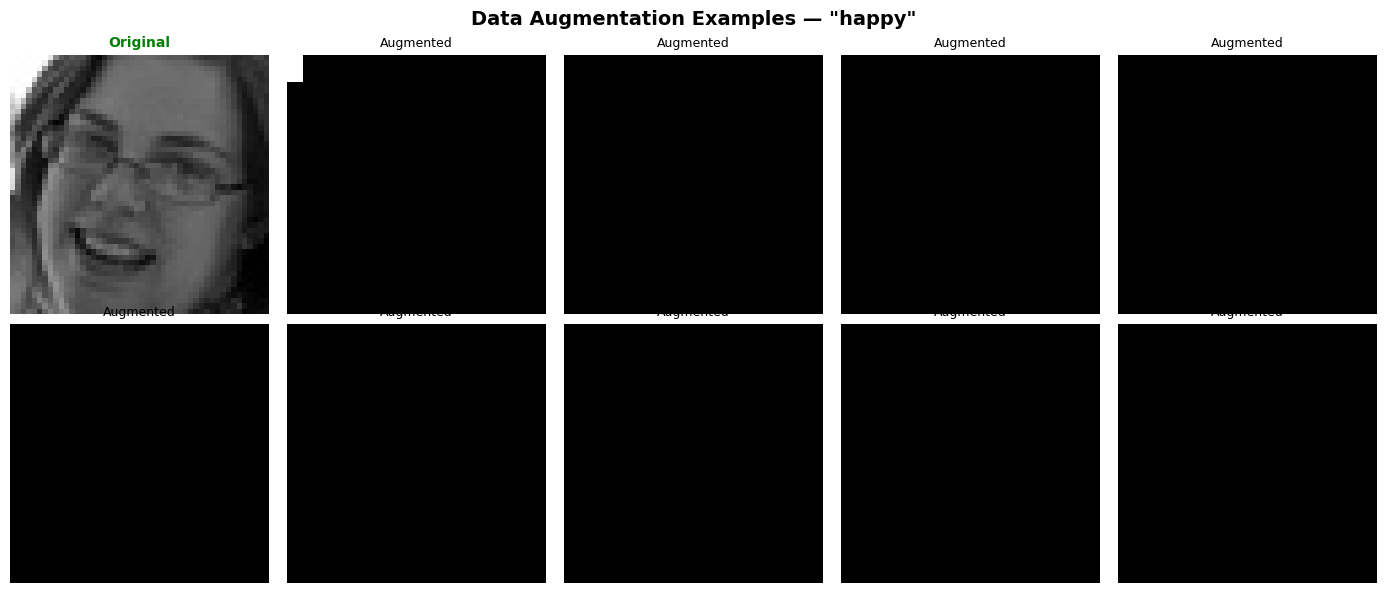

✅ Augmentation examples saved → 3_augmentation_examples.png


In [7]:
# ── Show augmentation examples ──
aug_datagen = ImageDataGenerator(
    rescale=1.0/255, rotation_range=15,
    width_shift_range=0.15, horizontal_flip=True,
    zoom_range=0.15, brightness_range=[0.7, 1.3]
)

# Pick one image from 'happy' folder (or first emotion available)
sample_emotion = EMOTION_LABELS[3] if len(EMOTION_LABELS) > 3 else EMOTION_LABELS[0]
sample_folder  = os.path.join(TRAIN_DIR, sample_emotion)
sample_files   = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.jpg','.png'))]
sample_img     = cv2.imread(os.path.join(sample_folder, sample_files[0]), cv2.IMREAD_GRAYSCALE)
sample_img_rs  = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_arr     = sample_img_rs.reshape(1, IMG_SIZE, IMG_SIZE, 1).astype('float32') / 255.0

aug_iter = aug_datagen.flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(f'Data Augmentation Examples — "{sample_emotion}"', fontsize=14, fontweight='bold')

axes[0, 0].imshow(sample_img_rs, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10, color='green', fontweight='bold')
axes[0, 0].axis('off')

positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for (r, c) in positions:
    aug_img = next(aug_iter)[0, :, :, 0]
    axes[r, c].imshow(aug_img, cmap='gray')
    axes[r, c].set_title('Augmented', fontsize=9)
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig('3_augmentation_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Augmentation examples saved → 3_augmentation_examples.png')

## 🧠 STEP 6 — Build the CNN Model

In [8]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    """
    Deep CNN for Facial Emotion Recognition.
    Architecture: 4 Conv Blocks + Dense Classifier
    """
    model = Sequential(name='FaceEmotionCNN')

    # ════════════════════════════
    #  BLOCK 1  →  64 filters
    # ════════════════════════════
    model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                     input_shape=input_shape, name='conv1_1'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), padding='same', activation='relu', name='conv1_2'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # ════════════════════════════
    #  BLOCK 2  →  128 filters
    # ════════════════════════════
    model.add(Conv2D(128, (3,3), padding='same', activation='relu', name='conv2_1'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), padding='same', activation='relu', name='conv2_2'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # ════════════════════════════
    #  BLOCK 3  →  256 filters
    # ════════════════════════════
    model.add(Conv2D(256, (3,3), padding='same', activation='relu', name='conv3_1'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), padding='same', activation='relu', name='conv3_2'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # ════════════════════════════
    #  BLOCK 4  →  512 filters
    # ════════════════════════════
    model.add(Conv2D(512, (3,3), padding='same', activation='relu', name='conv4_1'))
    model.add(BatchNormalization())
    model.add(Conv2D(512, (3,3), padding='same', activation='relu', name='conv4_2'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # ════════════════════════════
    #  CLASSIFIER HEAD
    # ════════════════════════════
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax', name='output'))

    return model


model = build_model()
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\n  Total Parameters    : {total_params:,}')
print(f'  Trainable Parameters: {trainable_params:,}')

Model: "FaceEmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,187,911 (27.42 MB)

 Trainable params: 7,182,535 (27.40 MB)

 Non-trainable params: 5,376 (21.00 KB)


  Total Parameters    : 7,187,911
  Trainable Parameters: 7,182,535


## ⚙️ STEP 7 — Compile the Model

In [9]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled!')
print(f'   Optimizer : Adam  (lr={LR})')
print(f'   Loss      : Categorical Crossentropy')
print(f'   Metrics   : Accuracy')

✅ Model compiled!
   Optimizer : Adam  (lr=0.001)
   Loss      : Categorical Crossentropy
   Metrics   : Accuracy


## 🎯 STEP 8 — Configure Callbacks

In [10]:
callbacks = [

    # ── Stop early when val_loss stops improving ──
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # ── Halve the learning rate if stuck for 5 epochs ──
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # ── Save the best model automatically ──
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('✅ Callbacks configured:')
print('   🛑 EarlyStopping     → patience=10, restore_best_weights=True')
print('   📉 ReduceLROnPlateau → patience=5,  factor=0.5')
print(f'   💾 ModelCheckpoint  → saves to: {MODEL_PATH}')

✅ Callbacks configured:
   🛑 EarlyStopping     → patience=10, restore_best_weights=True
   📉 ReduceLROnPlateau → patience=5,  factor=0.5
   💾 ModelCheckpoint  → saves to: emotion_model_best.h5


## 🚀 STEP 9 — Train the Model

In [11]:
print('=' * 60)
print('  🚀 TRAINING STARTED')
print(f'  Epochs     : up to {EPOCHS}  (EarlyStopping enabled)')
print(f'  Train steps: {len(train_gen)} batches/epoch')
print(f'  Val steps  : {len(test_gen)} batches/epoch')
print('=' * 60)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1
)

best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
epochs_run    = len(history.history['val_accuracy'])

print('\n' + '=' * 60)
print('  ✅ TRAINING COMPLETE!')
print(f'  Epochs run       : {epochs_run}')
print(f'  Best Val Accuracy: {best_val_acc * 100:.2f}%')
print(f'  Best Val Loss    : {best_val_loss:.4f}')
print(f'  Model saved to   : {MODEL_PATH}')
print('=' * 60)

  🚀 TRAINING STARTED
  Epochs     : up to 20  (EarlyStopping enabled)
  Train steps: 449 batches/epoch
  Val steps  : 113 batches/epoch
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1809 - loss: 2.5207   
Epoch 1: val_accuracy improved from None to 0.24882, saving model to emotion_model_best.h5



Epoch 1: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1758s 4s/step - accuracy: 0.2016 - loss: 2.2253 - val_accuracy: 0.2488 - val_loss: 1.8046 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2346 - loss: 1.9070   
Epoch 2: val_accuracy improved from 0.24882 to 0.32697, saving model to emotion_model_best.h5



Epoch 2: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 2024s 5s/step - accuracy: 0.2507 - loss: 1.8628 - val_accuracy: 0.3270 - val_loss: 1.7047 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3137 - loss: 1.7224   
Epoch 3: val_accuracy improved from 0.32697 to 0.41195, saving model to emotion_model_best.h5



Epoch 3: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1605s 4s/step - accuracy: 0.3377 - loss: 1.6693 - val_accuracy: 0.4120 - val_loss: 1.5690 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4187 - loss: 1.4982  
Epoch 4: val_accuracy improved from 0.41195 to 0.48064, saving model to emotion_model_best.h5



Epoch 4: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 71469s 159s/step - accuracy: 0.4337 - loss: 1.4644 - val_accuracy: 0.4806 - val_loss: 1.3658 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4837 - loss: 1.3562   
Epoch 5: val_accuracy did not improve from 0.48064
449/449 ━━━━━━━━━━━━━━━━━━━━ 1926s 4s/step - accuracy: 0.4911 - loss: 1.3387 - val_accuracy: 0.4744 - val_loss: 1.3709 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5099 - loss: 1.2871   
Epoch 6: val_accuracy improved from 0.48064 to 0.55754, saving model to emotion_model_best.h5


...


Epoch 14: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1869s 4s/step - accuracy: 0.6096 - loss: 1.0492 - val_accuracy: 0.6103 - val_loss: 1.0482 - learning_rate: 0.0010
Epoch 15/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6135 - loss: 1.0367   
Epoch 15: val_accuracy did not improve from 0.61034
449/449 ━━━━━━━━━━━━━━━━━━━━ 1919s 4s/step - accuracy: 0.6150 - loss: 1.0380 - val_accuracy: 0.6071 - val_loss: 1.0535 - learning_rate: 0.0010
Epoch 16/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6188 - loss: 1.0210   
Epoch 16: val_accuracy improved from 0.61034 to 0.61284, saving model to emotion_model_best.h5



Epoch 16: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1656s 4s/step - accuracy: 0.6203 - loss: 1.0208 - val_accuracy: 0.6128 - val_loss: 1.0311 - learning_rate: 0.0010
Epoch 17/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 41s/step - accuracy: 0.6270 - loss: 1.0031      
Epoch 17: val_accuracy did not improve from 0.61284
449/449 ━━━━━━━━━━━━━━━━━━━━ 18439s 41s/step - accuracy: 0.6256 - loss: 1.0099 - val_accuracy: 0.6011 - val_loss: 1.0628 - learning_rate: 0.0010
Epoch 18/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6310 - loss: 0.9939   
Epoch 18: val_accuracy improved from 0.61284 to 0.63082, saving model to emotion_model_best.h5



Epoch 18: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1640s 4s/step - accuracy: 0.6311 - loss: 0.9906 - val_accuracy: 0.6308 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 19/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6404 - loss: 0.9718  5
Epoch 19: val_accuracy improved from 0.63082 to 0.63876, saving model to emotion_model_best.h5



Epoch 19: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 1585s 4s/step - accuracy: 0.6373 - loss: 0.9779 - val_accuracy: 0.6388 - val_loss: 0.9605 - learning_rate: 0.0010
Epoch 20/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 74s/step - accuracy: 0.6407 - loss: 0.9638       
Epoch 20: val_accuracy improved from 0.63876 to 0.63959, saving model to emotion_model_best.h5



Epoch 20: finished saving model to emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 33431s 75s/step - accuracy: 0.6386 - loss: 0.9759 - val_accuracy: 0.6396 - val_loss: 0.9657 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 19.

  ✅ TRAINING COMPLETE!
  Epochs run       : 20
  Best Val Accuracy: 63.96%
  Best Val Loss    : 0.9605
  Model saved to   : emotion_model_best.h5


## 📈 STEP 10 — Plot Training History

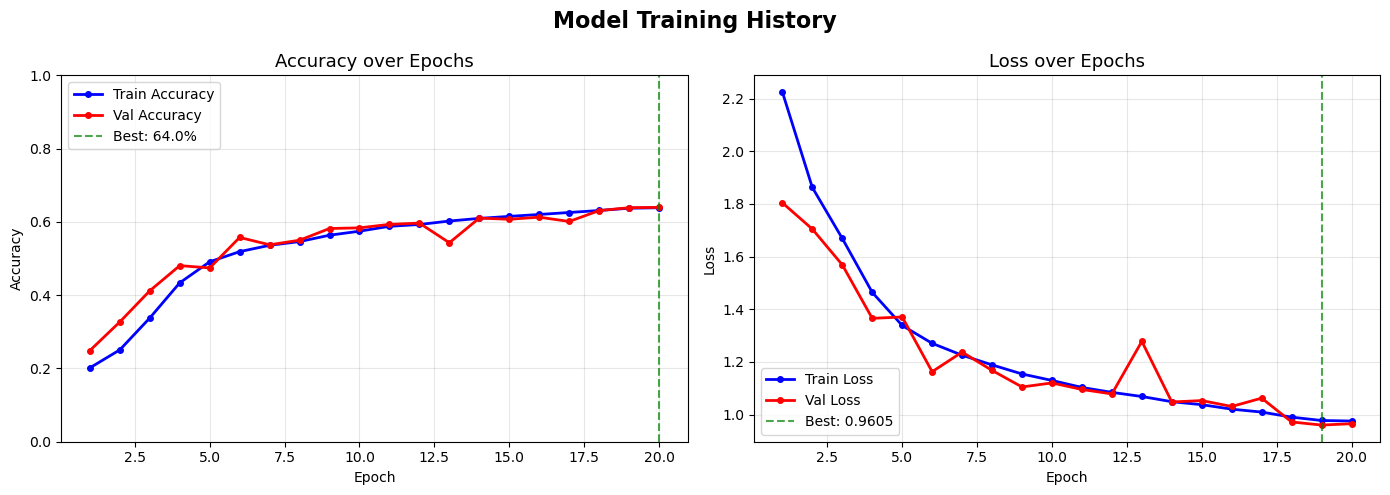

✅ Training history saved → 4_training_history.png


In [12]:
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

    # ── Accuracy plot ──
    axes[0].plot(epochs, acc,     'b-o', label='Train Accuracy', markersize=4, linewidth=2)
    axes[0].plot(epochs, val_acc, 'r-o', label='Val Accuracy',   markersize=4, linewidth=2)
    axes[0].axvline(val_acc.index(max(val_acc)) + 1, color='green',
                    linestyle='--', alpha=0.7, label=f'Best: {max(val_acc)*100:.1f}%')
    axes[0].set_title('Accuracy over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # ── Loss plot ──
    axes[1].plot(epochs, loss,     'b-o', label='Train Loss', markersize=4, linewidth=2)
    axes[1].plot(epochs, val_loss, 'r-o', label='Val Loss',   markersize=4, linewidth=2)
    axes[1].axvline(val_loss.index(min(val_loss)) + 1, color='green',
                    linestyle='--', alpha=0.7, label=f'Best: {min(val_loss):.4f}')
    axes[1].set_title('Loss over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('4_training_history.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Training history saved → 4_training_history.png')

plot_history(history)

## 🧪 STEP 11 — Evaluate the Model on Test Set

In [13]:
# ── Load the best saved model ──
best_model = load_model(MODEL_PATH)
print(f'✅ Best model loaded from: {MODEL_PATH}\n')

# ── Evaluate ──
test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)

print('=' * 40)
print('  📊 TEST SET RESULTS')
print('=' * 40)
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 40)

# ── Predict all test images ──
test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

print('\n📋 Classification Report:')
print('─' * 60)
print(classification_report(y_true, y_pred,
                             target_names=[e.capitalize() for e in EMOTION_LABELS]))
print('─' * 60)

✅ Best model loaded from: emotion_model_best.h5

  📊 TEST SET RESULTS
  Test Accuracy : 63.96%
  Test Loss     : 0.9657
113/113 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step

📋 Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Angry       0.55      0.59      0.57       958
     Disgust       0.67      0.20      0.31       111
        Fear       0.54      0.29      0.37      1024
       Happy       0.81      0.90      0.85      1774
     Neutral       0.52      0.77      0.62      1233
         Sad       0.57      0.41      0.48      1247
    Surprise       0.74      0.79      0.76       831

    accuracy                           0.64      7178
   macro avg       0.63      0.56      0.57      7178
weighted avg       0.64      0.64      0.62      7178

────────────────────────────────────────────────────────────


## 🔲 STEP 12 — Confusion Matrix

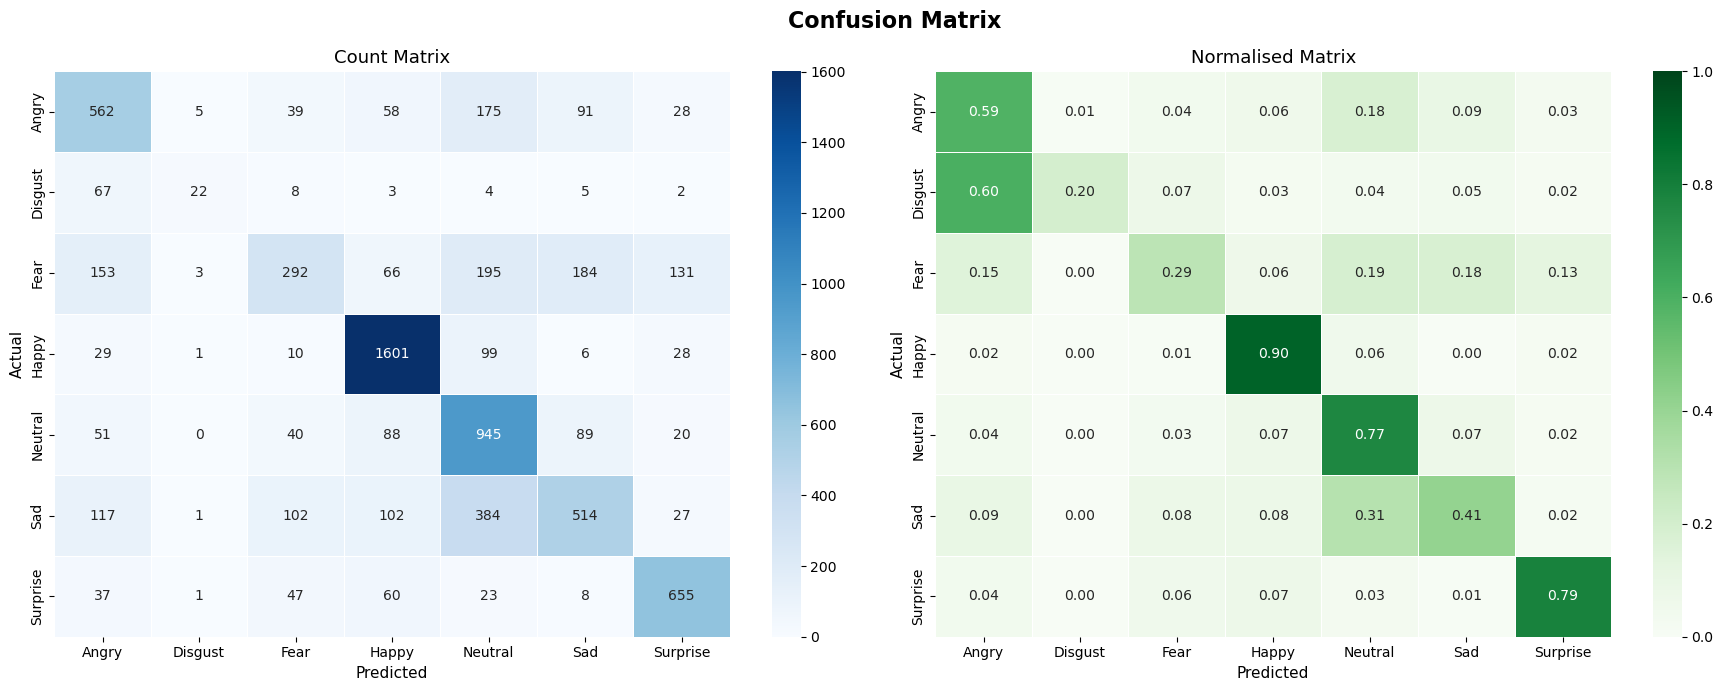

✅ Confusion matrix saved → 5_confusion_matrix.png


In [14]:
cm = confusion_matrix(y_true, y_pred)

# ── Raw count matrix ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix', fontsize=16, fontweight='bold')

labels = [e.capitalize() for e in EMOTION_LABELS]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Count Matrix', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual',    fontsize=11)

# ── Normalised (%) matrix ──
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Normalised Matrix', fontsize=13)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual',    fontsize=11)

plt.tight_layout()
plt.savefig('5_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved → 5_confusion_matrix.png')

## 🖼️ STEP 13 — Predict a Single Image

🖼️  Testing on: C:\Users\2005a\FED\archive\test\happy\PrivateTest_10077120.jpg


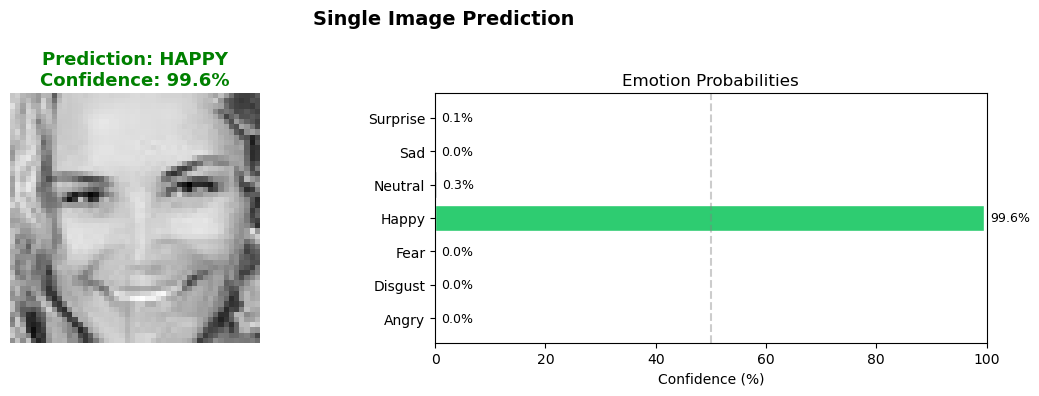


🎯 Predicted : HAPPY
📊 All scores:
   happy     : ███████████████████   99.6%
   neutral   :                        0.2%
   surprise  :                        0.1%
   fear      :                        0.0%
   sad       :                        0.0%
   angry     :                        0.0%
   disgust   :                        0.0%


In [15]:
def predict_single_image(image_path, model, show=True):
    """
    Predict emotion from any face image file.
    Returns: (predicted_emotion, confidence_dict)
    """
    # ── Load & preprocess ──
    img       = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_rs    = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm  = img_rs / 255.0
    img_input = img_norm.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    # ── Predict ──
    preds         = model.predict(img_input, verbose=0)[0]
    pred_idx      = np.argmax(preds)
    pred_emotion  = EMOTION_LABELS[pred_idx]
    confidence    = preds[pred_idx] * 100

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle('Single Image Prediction', fontsize=14, fontweight='bold')

        # Image
        axes[0].imshow(img_rs, cmap='gray')
        axes[0].set_title(
            f'Prediction: {pred_emotion.upper()}\nConfidence: {confidence:.1f}%',
            fontsize=13, fontweight='bold', color='green'
        )
        axes[0].axis('off')

        # Probability bar chart
        bar_colors = [COLORS[i] if i == pred_idx else '#BDC3C7' for i in range(NUM_CLASSES)]
        bars = axes[1].barh([e.capitalize() for e in EMOTION_LABELS],
                             preds * 100, color=bar_colors, edgecolor='white')
        axes[1].set_xlabel('Confidence (%)')
        axes[1].set_title('Emotion Probabilities')
        axes[1].set_xlim(0, 100)
        axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.4)
        for bar, val in zip(bars, preds * 100):
            axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                         f'{val:.1f}%', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

    return pred_emotion, {e: round(float(p)*100, 2) for e, p in zip(EMOTION_LABELS, preds)}


# ── Run prediction on a sample from the test set ──
sample_emo  = EMOTION_LABELS[3]  # 'happy'
sample_dir  = os.path.join(TEST_DIR, sample_emo)
sample_file = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg','.png'))][0]
sample_path = os.path.join(sample_dir, sample_file)

print(f'🖼️  Testing on: {sample_path}')
emotion, probs = predict_single_image(sample_path, best_model)

print(f'\n🎯 Predicted : {emotion.upper()}')
print('📊 All scores:')
for k, v in sorted(probs.items(), key=lambda x: -x[1]):
    bar = '█' * int(v // 5)
    print(f'   {k:10s}: {bar:20s} {v:5.1f}%')

## 🎲 STEP 14 — Grid of Random Test Predictions

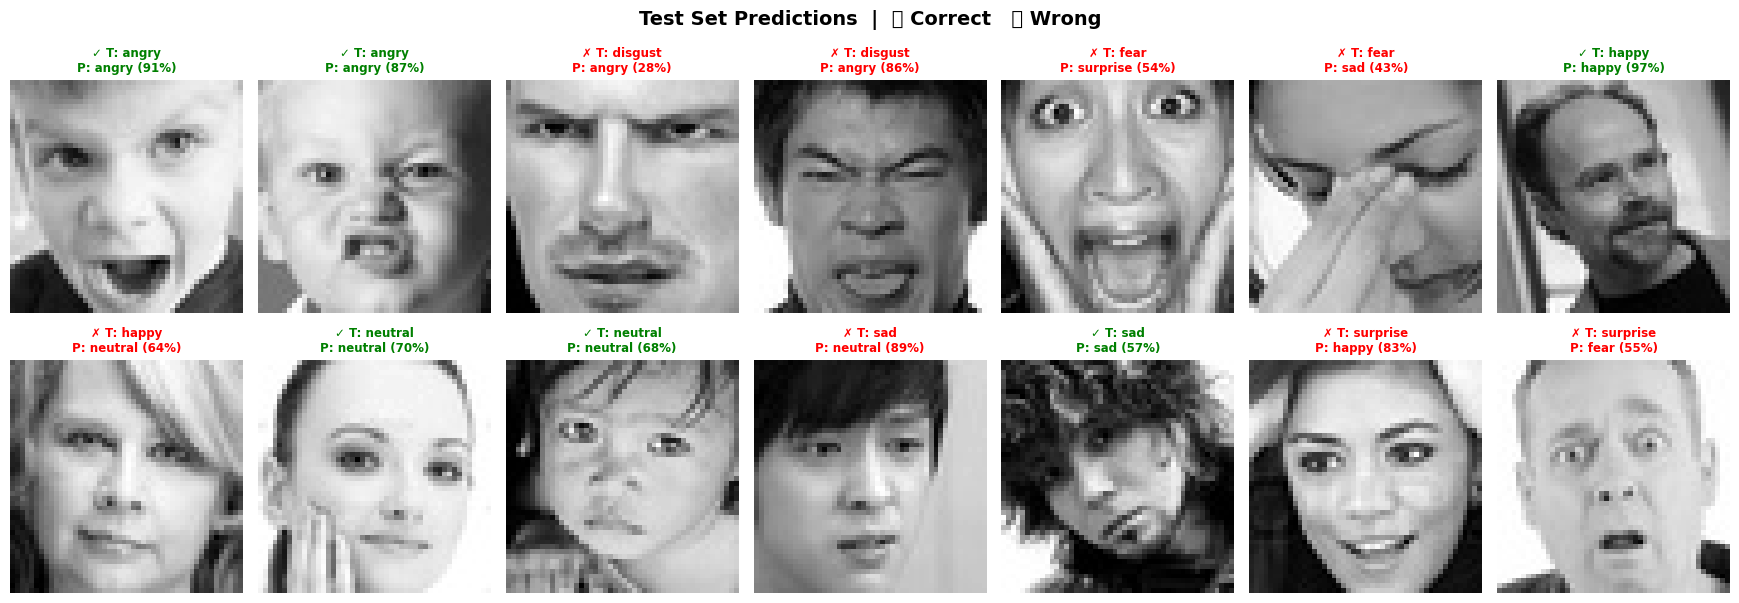

✅ Prediction grid saved → 6_prediction_grid.png


In [16]:
def visualize_predictions_grid(model, test_dir, n_per_class=2):
    """Show n_per_class random images per emotion with True/Predicted labels."""
    all_imgs, all_true, all_pred, all_conf = [], [], [], []

    for emotion in EMOTION_LABELS:
        folder = os.path.join(test_dir, emotion)
        files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png'))]
        chosen = np.random.choice(files, min(n_per_class, len(files)), replace=False)

        for fname in chosen:
            img_path = os.path.join(folder, fname)
            img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img_rs   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            inp      = (img_rs / 255.0).reshape(1, IMG_SIZE, IMG_SIZE, 1)
            preds    = model.predict(inp, verbose=0)[0]
            pred_idx = np.argmax(preds)

            all_imgs.append(img_rs)
            all_true.append(emotion)
            all_pred.append(EMOTION_LABELS[pred_idx])
            all_conf.append(preds[pred_idx] * 100)

    n    = len(all_imgs)
    cols = NUM_CLASSES
    rows = n_per_class

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3.2))
    if rows == 1: axes = axes.reshape(1, -1)
    fig.suptitle('Test Set Predictions  |  🟢 Correct   🔴 Wrong',
                 fontsize=14, fontweight='bold')

    for idx, (img, true, pred, conf) in enumerate(zip(all_imgs, all_true, all_pred, all_conf)):
        r, c = divmod(idx, cols)
        if r >= rows: break
        axes[r, c].imshow(img, cmap='gray')
        correct = (true == pred)
        color   = 'green' if correct else 'red'
        icon    = '✓' if correct else '✗'
        axes[r, c].set_title(
            f'{icon} T: {true}\nP: {pred} ({conf:.0f}%)',
            fontsize=8.5, color=color, fontweight='bold'
        )
        axes[r, c].axis('off')
        # Coloured border
        for spine in axes[r, c].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)

    plt.tight_layout()
    plt.savefig('6_prediction_grid.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Prediction grid saved → 6_prediction_grid.png')


np.random.seed(42)
visualize_predictions_grid(best_model, TEST_DIR, n_per_class=2)

## 🎥 STEP 15 — Real-Time Webcam Emotion Detection
> Detects your face via webcam and shows your emotion live.  
> **Press `Q` on the webcam window to quit.**

In [21]:
# ── Emotion → BGR colour map ──
EMOTION_BGR = {
    'angry'   : (0,   0,   255),
    'disgust' : (0,   128, 0  ),
    'fear'    : (128, 0,   128),
    'happy'   : (0,   215, 255),
    'neutral' : (200, 200, 200),
    'sad'     : (255, 100, 0  ),
    'surprise': (0,   255, 100)
}
# Emoji overlay
EMOTION_EMOJI = {
    'angry':'😠', 'disgust':'🤢', 'fear':'😨',
    'happy':'😊', 'neutral':'😐', 'sad':'😢', 'surprise':'😲'
}

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def run_webcam_detection(model, camera_index=0):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print('❌ Cannot open webcam. Check camera connection or camera_index.')
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    print('✅ Webcam started — press Q to quit')
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            print('⚠️  Frame capture failed.')
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5,
            minSize=(40, 40), flags=cv2.CASCADE_SCALE_IMAGE
        )

        for (x, y, w, h) in faces:
            # ── Preprocess ROI ──
            roi        = gray[y:y+h, x:x+w]
            roi_rs     = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
            roi_norm   = roi_rs / 255.0
            roi_input  = roi_norm.reshape(1, IMG_SIZE, IMG_SIZE, 1)

            # ── Predict ──
            preds       = model.predict(roi_input, verbose=0)[0]
            emo_idx     = np.argmax(preds)
            emo_label   = EMOTION_LABELS[emo_idx]
            confidence  = preds[emo_idx] * 100
            color       = EMOTION_BGR.get(emo_label, (255,255,255))

            # ── Draw face box ──
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

            # ── Label background ──
            label_text = f'{emo_label.upper()}  {confidence:.1f}%'
            (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_DUPLEX, 0.75, 1)
            label_y = max(y - 10, th + 10)
            cv2.rectangle(frame, (x, label_y - th - 6), (x + tw + 6, label_y + 4), color, -1)
            cv2.putText(frame, label_text, (x + 3, label_y),
                        cv2.FONT_HERSHEY_DUPLEX, 0.75, (0, 0, 0), 1, cv2.LINE_AA)

            # ── Mini sidebar probability bars ──
            bar_x = 10
            for i, (emo, prob) in enumerate(zip(EMOTION_LABELS, preds)):
                bar_y   = 15 + i * 26
                bar_len = int(prob * 120)
                emo_col = EMOTION_BGR.get(emo, (200,200,200))
                cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_len, bar_y + 16), emo_col, -1)
                cv2.rectangle(frame, (bar_x, bar_y), (bar_x + 120,     bar_y + 16), (80,80,80), 1)
                cv2.putText(frame, f'{emo[:3]:3s} {prob*100:4.1f}%',
                            (bar_x + 125, bar_y + 13),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255,255,255), 1)

        # ── FPS counter ──
        frame_count += 1
        cv2.putText(frame, f'Frame: {frame_count}', (10, 460),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)
        cv2.putText(frame, 'Press Q to quit', (460, 460),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

        cv2.imshow('😊 Face Emotion Recognition', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print('\n👋 Quitting webcam...')
            break

    cap.release()
    cv2.destroyAllWindows()
    print('✅ Webcam session ended.')


# ▶▶▶ LAUNCH WEBCAM  (press Q on the window to quit)
run_webcam_detection(best_model, camera_index=0)

✅ Webcam started — press Q to quit

👋 Quitting webcam...
✅ Webcam session ended.


## 💾 STEP 16 — Save Final Model

In [19]:
# ── Save in .h5 format ──
best_model.save('emotion_model_FINAL.h5')
print('✅ Saved → emotion_model_FINAL.h5')

# ── Save in TensorFlow SavedModel format (for deployment / TF Serving) ──
# Save Keras model
best_model.save('emotion_model_FINAL.keras')

# Save TensorFlow SavedModel (for deployment)
best_model.export('emotion_savedmodel/')
print('✅ Saved → emotion_savedmodel/')

# ── Save model config as JSON ──
model_json = best_model.to_json()
with open('emotion_model_config.json', 'w') as f:
    f.write(model_json)
print('✅ Saved → emotion_model_config.json')

# ── List all saved files ──
print('\n📁 Files in current directory:')
for f in sorted(os.listdir('.')):
    if any(f.endswith(ext) for ext in ['.h5', '.json', '.png']) or 'savedmodel' in f:
        size = os.path.getsize(f) if os.path.isfile(f) else 0
        print(f'   {f:45s}  {size/1024:.1f} KB' if size else f'   {f}/')

print('\n📌 To reload later:')
print('   from tensorflow.keras.models import load_model')
print('   model = load_model("emotion_model_FINAL.h5")')

✅ Saved → emotion_model_FINAL.h5
INFO:tensorflow:Assets written to: emotion_savedmodel/assets


INFO:tensorflow:Assets written to: emotion_savedmodel/assets


Saved artifact at 'emotion_savedmodel/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2114769245520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2114769245712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517471888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517470544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2114769241680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2114769243024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517472272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517476688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517476304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2113517472080: TensorSpec(shape=()

## 🔁 STEP 17 — Load & Use Saved Model (Future Sessions)

In [20]:
# ── Skip training next time — just load the saved model ──

from tensorflow.keras.models import load_model

loaded_model = load_model('emotion_model_FINAL.h5')
print('✅ Model loaded successfully!')
print(f'   Input  shape : {loaded_model.input_shape}')
print(f'   Output shape : {loaded_model.output_shape}')
print(f'   Parameters   : {loaded_model.count_params():,}')

# Quick sanity check — predict one image
test_gen.reset()
x_batch, y_batch = next(test_gen)
preds = loaded_model.predict(x_batch[:1], verbose=0)
idx   = np.argmax(preds[0])
print(f'\n  Sanity check prediction : {EMOTION_LABELS[idx].upper()} ({preds[0][idx]*100:.1f}%)')
print('✅ Loaded model works correctly!')

✅ Model loaded successfully!
   Input  shape : (None, 48, 48, 1)
   Output shape : (None, 7)
   Parameters   : 7,187,911

  Sanity check prediction : ANGRY (66.9%)
✅ Loaded model works correctly!


---
## ✅ Project Complete!

| Step | What was done |
|------|---------------|
| 1  | Installed all libraries |
| 2  | Imported dependencies |
| 3  | Set dataset path → `C:\Users\2005a\FED\archive` |
| 4  | Explored dataset distribution + sample images |
| 5  | Data augmentation (flip, rotate, zoom, brightness) |
| 6  | Built 4-block CNN (64→128→256→512 filters) |
| 7  | Compiled with Adam optimizer |
| 8  | Callbacks: EarlyStopping, ReduceLR, ModelCheckpoint |
| 9  | Trained model (up to 50 epochs) |
| 10 | Plotted accuracy & loss curves |
| 11 | Evaluated with classification report |
| 12 | Confusion matrix (count + normalised) |
| 13 | Single image prediction with bar chart |
| 14 | Grid of random test predictions |
| 15 | **Real-time webcam detection** 🎥 |
| 16 | Saved model (.h5 + SavedModel + JSON) |
| 17 | Load & reuse saved model |

### 📁 Output Files Generated
```
1_dataset_distribution.png
2_sample_images.png
3_augmentation_examples.png
4_training_history.png
5_confusion_matrix.png
6_prediction_grid.png
emotion_model_best.h5        ← auto-saved during training
emotion_model_FINAL.h5       ← final complete model
emotion_savedmodel/          ← TF serving format
emotion_model_config.json    ← architecture only
```

### 💡 Tips to Improve Accuracy
- Use **Transfer Learning** (MobileNetV2, VGG16, EfficientNet)
- Apply **class weights** to fix class imbalance
- Try **Label Smoothing** in the loss function
- Add **Mixup / CutMix** augmentation
- Train longer with **Cosine Annealing** learning rate schedule